# **Regression**

## Objectives

*   Fit and evaluate a regression model to predict SalePrice


## Inputs

* outputs/datasets/collection/house_prices_records.csv
* Instructions on which variables to use for data cleaning and feature engineering. They are found in their respective notebooks.

## Outputs

* Train set (features and target)
* Test set (features and target)
* ML pipeline to predict SalePrice
* Feature Importance Plot



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir


'c:\\Users\\farib\\Projects\\Heritage-House-Price-Insight-Predictor\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")


You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir


'c:\\Users\\farib\\Projects\\Heritage-House-Price-Insight-Predictor'

# Load Data

In [4]:
import numpy as np
import pandas as pd
df = (pd.read_csv("outputs/datasets/collection/house_prices_records.csv")
      )

print(df.shape)
df.head(3)


(1460, 24)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,68.0,162.0,42,5,7,920,NaN,2001,2002,223500


In [5]:
df_modeling = df.copy()
df_modeling.head(3)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,68.0,162.0,42,5,7,920,NaN,2001,2002,223500


We add the binary flags (HasOpenPorch, HasMasonry) before the pipeline.
Pipelines do not support dynamic column creation inside by default — so we do this outside and feed into TrainSet.

In [6]:
# Create binary indicator columns
df_modeling['HasOpenPorch'] = (df_modeling['OpenPorchSF'] > 0).astype(int)
df_modeling['HasMasonry'] = (df_modeling['MasVnrArea'] > 0).astype(int)


---

# MP Pipeline: Regressor

## Create ML pipeline

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from feature_engine.imputation import (
    MeanMedianImputer,
    CategoricalImputer,
    ArbitraryNumberImputer
)
from feature_engine.selection import DropFeatures
from feature_engine.encoding import OrdinalEncoder
from feature_engine.transformation import (
    PowerTransformer,
    BoxCoxTransformer,
    YeoJohnsonTransformer,
    LogTransformer
)

# ML algorithms
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor


def PipelineOptimization(model):
    """
    Builds and returns a Scikit-learn pipeline for training a regression model,
    including steps for data cleaning, feature engineering, scaling, selection,
    and final modeling.

    Parameters:
    -----------
    model : sklearn-compatible estimator
        A machine learning model (e.g., LinearRegression,
        RandomForestRegressor)
        to be optimized using feature selection and final prediction.

    Returns:
    --------
    sklearn.pipeline.Pipeline
        A pipeline object that includes preprocessing and modeling steps.
    """

    modeling_pipeline = Pipeline([

        # --- 1. Data Cleaning ---
        ("drop_features", DropFeatures(
            features_to_drop=["EnclosedPorch", "WoodDeckSF"]
        )),

        # Impute missing numerical values using median
        ("median_imputer", MeanMedianImputer(
            imputation_method="median",
            variables=["2ndFlrSF", "BedroomAbvGr", "LotFrontage"]
        )),

        # Impute missing year of garage build with a constant value
        ("constant_imputer", ArbitraryNumberImputer(
            arbitrary_number=1900.0,
            variables=["GarageYrBlt"]
        )),

        # Impute missing categorical values using the mode
        ("mode_imputer", CategoricalImputer(
            imputation_method="frequent",
            variables=["BsmtExposure", "BsmtFinType1", "GarageFinish"]
        )),

        # --- 2. Feature Engineering ---

        # 2.1 Drop sparse features already converted to binary elsewhere
        ("drop_sparse", DropFeatures(
            features_to_drop=["OpenPorchSF", "MasVnrArea"]
        )),

        # 2.2 Encode categorical ordinal features
        ("ordinal_encoder", OrdinalEncoder(
            encoding_method="arbitrary",
            variables=["BsmtExposure", "BsmtFinType1",
                       "GarageFinish", "KitchenQual"]
        )),

        # 2.3 Apply power transformation to reduce skewness
        ("power_1stFlrSF", PowerTransformer(variables=["1stFlrSF"])),

        # Yeo-Johnson transformation for a group of numerical variables
        ("yeojohnson_group1", YeoJohnsonTransformer(
            variables=[
                "BedroomAbvGr", "BsmtFinSF1", "BsmtUnfSF", "GarageArea",
                "YearBuilt", "YearRemodAdd", "GrLivArea", "LotArea",
                "LotFrontage", "OverallCond", "TotalBsmtSF"
            ]
        )),

        # Log transformation for GarageYrBlt (log base 10)
        ("log_garageyrblt", LogTransformer(variables=["GarageYrBlt"],
                                           base="10")),

        # Box-Cox transformation for OverallQual
        ("boxcox_overallqual", BoxCoxTransformer(variables=["OverallQual"])),

        # 2.4 Drop remaining correlated features
        ("drop_correlated", DropFeatures(
            features_to_drop=["1stFlrSF", "GarageYrBlt"]
        )),

        # --- 3. Feature Scaling ---
        ("feat_scaling", StandardScaler()),

        # --- 4. Feature Selection ---
        # Select best features using the passed model as estimator
        ("feat_selection", SelectFromModel(estimator=model)),

        # --- 5. Final Model ---
        # Train the final model using remaining features
        ("model", model)
    ])

    return modeling_pipeline


Custom Class for hyperparameter optimisation

In [8]:
from sklearn.model_selection import GridSearchCV


class HyperparameterOptimizationSearch:
    """
    A helper class to perform hyperparameter optimization using GridSearchCV
    for multiple models and summarize their performance.

    Attributes:
    models : dict
        A dictionary of model names and sklearn estimator objects.
    params : dict
        A dictionary of model names and parameter grids corresponding
        to each model.
    keys : list
        List of keys (model names) from the models dictionary.
    grid_searches : dict
        Stores the fitted GridSearchCV objects for each model.
    """

    def __init__(self, models, params):
        """
        Initializes the class with models and their corresponding
        parameter grids.

        Parameters:
        models : dict
            A dictionary of model names and sklearn estimator objects.
        params : dict
            A dictionary of model names and parameter grids.
        """
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        """
        Fit GridSearchCV for each model in the dictionary.

        Parameters:
        X : pd.DataFrame
            Feature matrix.
        y : pd.Series or np.array
            Target vector.
        cv : int or cross-validation generator
            Number of folds or CV splitter.
        n_jobs : int
            Number of jobs to run in parallel.
        verbose : int, default=1
            Controls the verbosity of GridSearchCV.
        scoring : str or callable, default=None
            Strategy to evaluate the performance of the cross-validated model.
        refit : bool, default=False
            Refit the estimator using the best parameters on the whole dataset.
        """
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")
            model = PipelineOptimization(self.models[key])

            params = self.params[key]  # Get parameter grid
            gs = GridSearchCV(
                model, params, cv=cv, n_jobs=n_jobs,
                verbose=verbose, scoring=scoring
            )
            gs.fit(X, y)  # Fit the model
            self.grid_searches[key] = gs  # Store the fitted object

    def score_summary(self, sort_by='mean_score'):
        """
        Generate a summary DataFrame showing performance of each
        hyperparameter setting.

        Parameters:
        sort_by : str, default='mean_score'
            Metric to sort the results by.

        Returns:
        pd.DataFrame
            Summary of GridSearchCV results including min, max, mean,
            std scores and parameters.
        dict
            Dictionary of fitted GridSearchCV objects.
        """

        def row(key, scores, params):
            # Create a row summarizing scores and parameters
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []

            # Collect scores from each CV split
            for i in range(self.grid_searches[k].cv):
                key = f"split{i}_test_score"
                r = self.grid_searches[k].cv_results_[key]
                # shape: (n_combinations, 1)
                scores.append(r.reshape(len(params), 1))

            # Stack scores horizontally and pair with parameters
            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append((row(k, s, p)))

        # Create DataFrame, sort, and organize columns
        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)

        columns = ['estimator', 'min_score', 'mean_score',
                   'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]

        return df[columns], self.grid_searches


---

## Split Train Test Set

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['SalePrice'], axis=1),
    df['SalePrice'],
    test_size=0.2,
    random_state=0
)

print("* Train set:", X_train.shape, y_train.shape,
      "\n* Test set:",  X_test.shape, y_test.shape)


* Train set: (1168, 23) (1168,) 
* Test set: (292, 23) (292,)


## Grid Search CV - Sklearn

### Use default hyperparameters to find most suitable algorithm

In [10]:
models_quick_search = {
    'LinearRegression': LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=0),
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=0),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=0),
    "XGBRegressor": XGBRegressor(random_state=0),
}

params_quick_search = {
    'LinearRegression': {},
    "DecisionTreeRegressor": {},
    "RandomForestRegressor": {},
    "ExtraTreesRegressor": {},
    "AdaBoostRegressor": {},
    "GradientBoostingRegressor": {},
    "XGBRegressor": {},
}


Do a hyperparameter optimisation search using default hyperparameters

In [11]:
import warnings
warnings.filterwarnings('ignore')
search = HyperparameterOptimizationSearch(models=models_quick_search,
                                          params=params_quick_search)
search.fit(X_train, y_train, scoring='r2', n_jobs=-1, cv=5)



Running GridSearchCV for LinearRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for DecisionTreeRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for XGBRegressor 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


Check results

In [12]:
grid_search_summary, grid_search_pipelines = search.score_summary(
    sort_by='mean_score')
grid_search_summary


,estimator,min_score,mean_score,max_score,std_score
3,ExtraTreesRegressor,0.687196,0.806634,0.876414,0.066019
0,LinearRegression,0.725435,0.783554,0.831805,0.037744
2,RandomForestRegressor,0.688748,0.771163,0.817518,0.047465
5,GradientBoostingRegressor,0.635793,0.768874,0.831192,0.070259
4,AdaBoostRegressor,0.645653,0.752746,0.797178,0.056209
6,XGBRegressor,0.589023,0.66983,0.751455,0.056743
1,DecisionTreeRegressor,0.494971,0.579547,0.667303,0.063698


ExtraTreesRegressor has the highest average R² but also the highest variance (std = 0.066). This could indicate that it’s sensitive to data variation.

LinearRegression shows stable performance (low std = 0.0377) and does surprisingly well, meaning the engineered features capture linear trends effectively.

XGBRegressor and DecisionTreeRegressor underperform here, which might suggest that either:

* The hyperparameters are suboptimal,

* The models are overfitting (especially for trees),

* Or the ensemble power of RandomForest/ExtraTrees outperforms single models.

### Do an extensive search on the most suitable model (ExtraTreesRegressor) to find the best hyperparameter configuration.

Define model and parameters, for Extensive Search

In [13]:
models_search = {
    "ExtraTreesRegressor": ExtraTreesRegressor(random_state=0),
}

# documentation to help on hyperparameter list:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesRegressor.html

# We will not conduct an extensive search, since the focus
# is on how to combine all knowledge in an applied project.
# In a workplace project, you may consider more hyperparameters and spend
# more time in this step

params_search = {
    "ExtraTreesRegressor": {
        'model__n_estimators': [100, 150, 200],
        'model__max_depth': [5, 10, 15, 20],
        'model__min_samples_split': [5, 10, 15],
        'model__min_samples_leaf': [2, 4, 6],
        'model__max_features': ['sqrt', 'log2'],
        'model__criterion': ['absolute_error']
    }
}


Extensive GridSearch CV

In [14]:
search = HyperparameterOptimizationSearch(models=models_search,
                                          params=params_search)
search.fit(X_train, y_train, scoring='r2', n_jobs=-1, cv=5, verbose=1)



Running GridSearchCV for ExtraTreesRegressor 

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


Check results

In [15]:
grid_search_summary, grid_search_pipelines = search.score_summary(
    sort_by='mean_score')
grid_search_summary


,estimator,min_score,mean_score,max_score,std_score,model__criterion,model__max_depth,model__max_features,model__min_samples_leaf,model__min_samples_split,model__n_estimators
137,ExtraTreesRegressor,0.774629,0.826423,0.863838,0.034495,absolute_error,15,log2,2,5,200
110,ExtraTreesRegressor,0.774629,0.826423,0.863838,0.034495,absolute_error,15,sqrt,2,5,200
136,ExtraTreesRegressor,0.776974,0.8255,0.862011,0.033949,absolute_error,15,log2,2,5,150
109,ExtraTreesRegressor,0.776974,0.8255,0.862011,0.033949,absolute_error,15,sqrt,2,5,150
191,ExtraTreesRegressor,0.777825,0.825418,0.860575,0.033066,absolute_error,20,log2,2,5,200
...,...,...,...,...,...,...,...,...,...,...,...
52,ExtraTreesRegressor,0.672069,0.716297,0.752457,0.029981,absolute_error,5,log2,6,15,150
46,ExtraTreesRegressor,0.673489,0.715623,0.753643,0.030407,absolute_error,5,log2,6,5,150
49,ExtraTreesRegressor,0.673489,0.715623,0.753643,0.030407,absolute_error,5,log2,6,10,150
22,ExtraTreesRegressor,0.673489,0.715623,0.753643,0.030407,absolute_error,5,sqrt,6,10,150


Check the best model

In [16]:
best_model_extra_trees = grid_search_summary.iloc[0, 0]
best_model_extra_trees


'ExtraTreesRegressor'

Parameters for best model

In [17]:
grid_search_pipelines[best_model_extra_trees].best_params_


{'model__criterion': 'absolute_error',
 'model__max_depth': 15,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 5,
 'model__n_estimators': 200}

Define the best regressor, based on search

In [18]:
best_regressor_pipeline_extra_trees = grid_search_pipelines[
    best_model_extra_trees].best_estimator_
best_regressor_pipeline_extra_trees


Pipeline(steps=[('drop_features',
                 DropFeatures(features_to_drop=['EnclosedPorch',
                                                'WoodDeckSF'])),
                ('median_imputer',
                 MeanMedianImputer(variables=['2ndFlrSF', 'BedroomAbvGr',
                                              'LotFrontage'])),
                ('constant_imputer',
                 ArbitraryNumberImputer(arbitrary_number=1900.0,
                                        variables=['GarageYrBlt'])),
                ('mode_imputer',
                 CategoricalImputer(imputation_method='frequent',
                                    varia...
                ('drop_correlated',
                 DropFeatures(features_to_drop=['1stFlrSF', 'GarageYrBlt'])),
                ('feat_scaling', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=ExtraTreesRegressor(random_state=0))),
                ('model',
                 ExtraTreesRegressor(criterion='absolute_error', max_depth=15,
                                     max_features='sqrt', min_samples_leaf=2,
                                     min_samples_split=5, n_estimators=200,
                                     random_state=0))])

## Assess feature importance

* These are the 5 most important features in descending order:
['OverallQual', 'GrLivArea', 'YearBuilt', 'TotalBsmtSF', 'GarageArea']


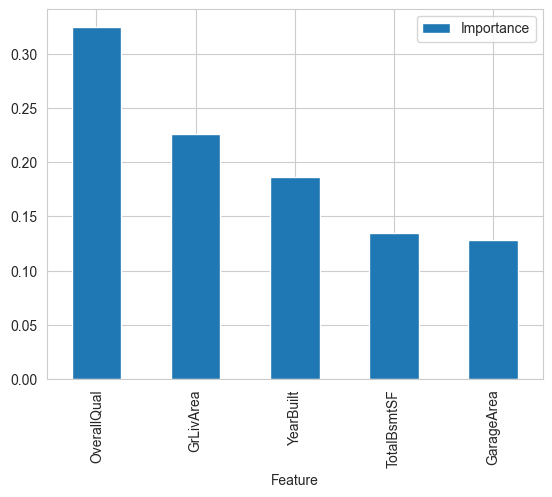

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Extract steps before scaling (up to but not including 'feat_selection')
data_cleaning_feat_eng_steps = 12
X_transformed = Pipeline(
    best_regressor_pipeline_extra_trees.steps[:data_cleaning_feat_eng_steps]
    ).transform(X_train)

# Manually assign column names from X_train, after all previous transformations
# (Assumes that the transformation preserves column order)
columns_before_selection = X_train.columns

# If your pipeline drops/adds columns, it's safer
# to extract names before scaling:
# Step 1: run pipeline up to just before 'feat_scaling'
# up to 'drop_correlated'
pipeline_before_scaling = Pipeline(
        best_regressor_pipeline_extra_trees.steps[:11])
X_engineered = pipeline_before_scaling.transform(X_train)

# Step 2: wrap in DataFrame to keep column names
X_engineered_df = pd.DataFrame(X_engineered, columns=X_engineered.columns)

# Step 3: get support from SelectFromModel
mask = best_regressor_pipeline_extra_trees['feat_selection'].get_support()
best_features = X_engineered_df.columns[mask].to_list()

# Step 4: plot feature importances
df_feature_importance_extra_trees = pd.DataFrame({
    'Feature': best_features,
    'Importance': best_regressor_pipeline_extra_trees[
            'model'].feature_importances_
}).sort_values(by='Importance', ascending=False)

print(f"* These are the {len(best_features)} most important"
      f" features in descending order:\n"
      f"{df_feature_importance_extra_trees['Feature'].to_list()}")

# Plot
df_feature_importance_extra_trees.plot(kind='bar', x='Feature', y='Importance')
plt.show()


### Do an extensive search on Ridge and Lasso to find the best hyperparameter configuration.

Define model and parameters, for Extensive Search

In [20]:
from sklearn.linear_model import Ridge, Lasso

models_search = {
    "Ridge": Ridge(random_state=0),
    "Lasso": Lasso(random_state=0),
}

params_search = {
    "Ridge": {
        'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
        'model__solver': ['auto', 'svd', 'cholesky', 'sparse_cg']
    },
    "Lasso": {
        'model__alpha': [0.01, 0.1, 1.0, 10.0],
        'model__selection': ['cyclic', 'random'],
        'model__max_iter': [1000, 5000]
    }
}


Extensive GridSearch CV

In [21]:
search = HyperparameterOptimizationSearch(models=models_search,
                                          params=params_search)
search.fit(X_train, y_train, scoring='r2', n_jobs=-1, cv=3, verbose=1)



Running GridSearchCV for Ridge 

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Running GridSearchCV for Lasso 

Fitting 3 folds for each of 16 candidates, totalling 48 fits


Check results

In [22]:
grid_search_summary, grid_search_pipelines = search.score_summary(
    sort_by='mean_score')
grid_search_summary


,estimator,min_score,mean_score,max_score,std_score,model__alpha,model__solver,model__max_iter,model__selection
34,Lasso,0.800424,0.814705,0.825643,0.010563,10.0,NaN,5000,cyclic
32,Lasso,0.800424,0.814705,0.825643,0.010563,10.0,NaN,1000,cyclic
28,Lasso,0.800364,0.814705,0.825628,0.010593,1.0,NaN,1000,cyclic
30,Lasso,0.800364,0.814705,0.825628,0.010593,1.0,NaN,5000,cyclic
26,Lasso,0.800358,0.814704,0.825626,0.010596,0.1,NaN,5000,cyclic
24,Lasso,0.800358,0.814704,0.825626,0.010596,0.1,NaN,1000,cyclic
27,Lasso,0.800358,0.814704,0.825626,0.010596,0.1,NaN,5000,random
25,Lasso,0.800358,0.814704,0.825626,0.010596,0.1,NaN,1000,random
23,Lasso,0.800357,0.814704,0.825626,0.010596,0.01,NaN,5000,random
21,Lasso,0.800357,0.814704,0.825626,0.010596,0.01,NaN,1000,random


Check the best model

In [23]:
best_model_lasso = grid_search_summary.iloc[0, 0]
best_model_lasso


'Lasso'

Parameters for best model

In [24]:
grid_search_pipelines[best_model_lasso].best_params_


{'model__alpha': 10.0, 'model__max_iter': 1000, 'model__selection': 'cyclic'}

Define the best regressor, based on search

In [25]:
best_regressor_pipeline_lasso = grid_search_pipelines[
    best_model_lasso].best_estimator_
best_regressor_pipeline_lasso


Pipeline(steps=[('drop_features',
                 DropFeatures(features_to_drop=['EnclosedPorch',
                                                'WoodDeckSF'])),
                ('median_imputer',
                 MeanMedianImputer(variables=['2ndFlrSF', 'BedroomAbvGr',
                                              'LotFrontage'])),
                ('constant_imputer',
                 ArbitraryNumberImputer(arbitrary_number=1900.0,
                                        variables=['GarageYrBlt'])),
                ('mode_imputer',
                 CategoricalImputer(imputation_method='frequent',
                                    varia...
                ('log_garageyrblt',
                 LogTransformer(base='10', variables=['GarageYrBlt'])),
                ('boxcox_overallqual',
                 BoxCoxTransformer(variables=['OverallQual'])),
                ('drop_correlated',
                 DropFeatures(features_to_drop=['1stFlrSF', 'GarageYrBlt'])),
                ('feat_scaling', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=Lasso(random_state=0))),
                ('model', Lasso(alpha=10.0, random_state=0))])

## Coefficient analysis

In [26]:
def linear_model_coefficients(model, columns):
    """
    Display and plot the coefficients of a trained linear model.

    Parameters:
    model : sklearn.linear_model
        A trained linear model.
        Must have `coef_` and `intercept_` attributes.

    columns : list of str
        List of feature names corresponding to the model coefficients.

    Output:
    - Prints the model's intercept.
    - Displays a sorted DataFrame of features and their coefficients.
    - Plots a bar chart of feature importances based on
      absolute coefficient values.
    """
    # Print the intercept (constant term) of the linear model
    print(f"* Interception: {model.intercept_}")

    # Create a DataFrame mapping features to their coefficients
    coeff_df = pd.DataFrame({
        'Feature': columns,
        'Coefficient': model.coef_
    }).sort_values(by='Coefficient', key=abs, ascending=False)

    print("* Coefficients")
    print(coeff_df)

    # Plot the coefficients using a bar chart
    coeff_df.plot(kind='bar', x='Feature', y='Coefficient')
    plt.title("Feature Importance (Linear Model Coefficients)")
    plt.tight_layout()
    plt.show()


* Interception: 180808.89897260268
* Coefficients
         Feature   Coefficient
13   OverallQual  23280.076972
8      GrLivArea  22366.869094
14   TotalBsmtSF  18637.612383
15     YearBuilt  12315.720281
10       LotArea   9484.953592
9    KitchenQual   9215.149869
16  YearRemodAdd   7763.428305
5      BsmtUnfSF  -7701.067314
0       2ndFlrSF   7149.518215
6     GarageArea   6866.663458
1   BedroomAbvGr  -5749.132771
12   OverallCond   5676.417839
3     BsmtFinSF1   3232.779314
11   LotFrontage   2498.596469
4   BsmtFinType1  -1737.157489
2   BsmtExposure   1316.684363
7   GarageFinish   -105.570792


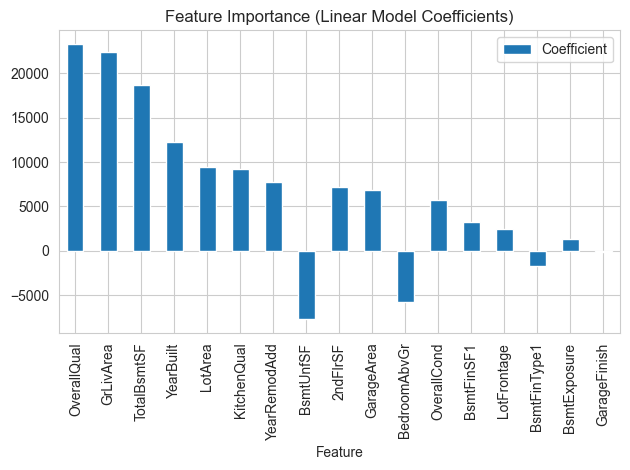

In [27]:
# Step 1: Run pipeline up to just before 'feat_selection'
pipeline_before_selection = Pipeline(best_regressor_pipeline_lasso.steps[:12])
X_engineered = pipeline_before_selection.transform(X_train)

# Step 2: Infer correct column names dynamically
# This assumes you're using feature_engine transformers which store variables_
feature_names = []

for name, step in pipeline_before_selection.steps:
    if hasattr(step, 'variables_'):
        feature_names = step.variables_
    elif hasattr(step, 'get_feature_names_out'):
        feature_names = step.get_feature_names_out()
    # fall back to current columns
    elif isinstance(X_train, pd.DataFrame):
        feature_names = X_train.columns

# Now verify shape matches
X_engineered_df = pd.DataFrame(X_engineered, columns=feature_names)

# Step 3: Get selected features by name
mask = best_regressor_pipeline_lasso['feat_selection'].get_support()
selected_features = X_engineered_df.columns[mask].to_list()

# Step 4: Plot and print coefficients
linear_model_coefficients(best_regressor_pipeline_lasso['model'],
                          selected_features)


### Do an extensive search on RandomForestRegressor model to find the best hyperparameter configuration.

Define model and parameters, for Extensive Search

Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

In [28]:
from sklearn.ensemble import RandomForestRegressor

models_search = {
    "RandomForestRegressor": RandomForestRegressor(random_state=0),
}

params_search = {
    "RandomForestRegressor": {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf': [1, 2],
        'model__max_features': ['sqrt', 'log2'],
        'model__criterion': ['squared_error', 'absolute_error'],
    }
}


Extensive GridSearch CV

In [29]:
search = HyperparameterOptimizationSearch(models=models_search,
                                          params=params_search)
search.fit(X_train, y_train, scoring='r2', n_jobs=-1, cv=3, verbose=1)



Running GridSearchCV for RandomForestRegressor 

Fitting 3 folds for each of 192 candidates, totalling 576 fits


Check results

In [30]:
grid_search_summary, grid_search_pipelines = search.score_summary(
    sort_by='mean_score')
grid_search_summary


,estimator,min_score,mean_score,max_score,std_score,model__criterion,model__max_depth,model__max_features,model__min_samples_leaf,model__min_samples_split,model__n_estimators
140,RandomForestRegressor,0.705335,0.785292,0.825846,0.05654,absolute_error,10,log2,2,2,300
128,RandomForestRegressor,0.705335,0.785292,0.825846,0.05654,absolute_error,10,sqrt,2,2,300
165,RandomForestRegressor,0.704594,0.785205,0.826297,0.057004,absolute_error,20,log2,2,5,100
153,RandomForestRegressor,0.704594,0.785205,0.826297,0.057004,absolute_error,20,sqrt,2,5,100
130,RandomForestRegressor,0.705013,0.785176,0.827294,0.056709,absolute_error,10,sqrt,2,5,200
...,...,...,...,...,...,...,...,...,...,...,...
49,RandomForestRegressor,0.628511,0.758994,0.827741,0.09231,squared_error,20,sqrt,1,2,200
85,RandomForestRegressor,0.626964,0.7581,0.826696,0.09276,squared_error,30,log2,1,2,200
73,RandomForestRegressor,0.626964,0.7581,0.826696,0.09276,squared_error,30,sqrt,1,2,200
1,RandomForestRegressor,0.626964,0.7581,0.826696,0.09276,squared_error,None,sqrt,1,2,200


Check the best model

In [31]:
best_model_random_forest = grid_search_summary.iloc[0, 0]
best_model_random_forest


'RandomForestRegressor'

Parameters for best model

In [32]:
grid_search_pipelines[best_model_random_forest].best_params_


{'model__criterion': 'absolute_error',
 'model__max_depth': 10,
 'model__max_features': 'sqrt',
 'model__min_samples_leaf': 2,
 'model__min_samples_split': 2,
 'model__n_estimators': 300}

Define the best regressor, based on search

In [33]:
best_regressor_pipeline_random_forest = grid_search_pipelines[
    best_model_random_forest].best_estimator_
best_regressor_pipeline_random_forest


Pipeline(steps=[('drop_features',
                 DropFeatures(features_to_drop=['EnclosedPorch',
                                                'WoodDeckSF'])),
                ('median_imputer',
                 MeanMedianImputer(variables=['2ndFlrSF', 'BedroomAbvGr',
                                              'LotFrontage'])),
                ('constant_imputer',
                 ArbitraryNumberImputer(arbitrary_number=1900.0,
                                        variables=['GarageYrBlt'])),
                ('mode_imputer',
                 CategoricalImputer(imputation_method='frequent',
                                    varia...
                 BoxCoxTransformer(variables=['OverallQual'])),
                ('drop_correlated',
                 DropFeatures(features_to_drop=['1stFlrSF', 'GarageYrBlt'])),
                ('feat_scaling', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=RandomForestRegressor(random_state=0))),
                ('model',
                 RandomForestRegressor(criterion='absolute_error', max_depth=10,
                                       max_features='sqrt', min_samples_leaf=2,
                                       n_estimators=300, random_state=0))])

## Assess feature importance

* These are the 3 most important features in descending order:
['GrLivArea', 'OverallQual', 'TotalBsmtSF']


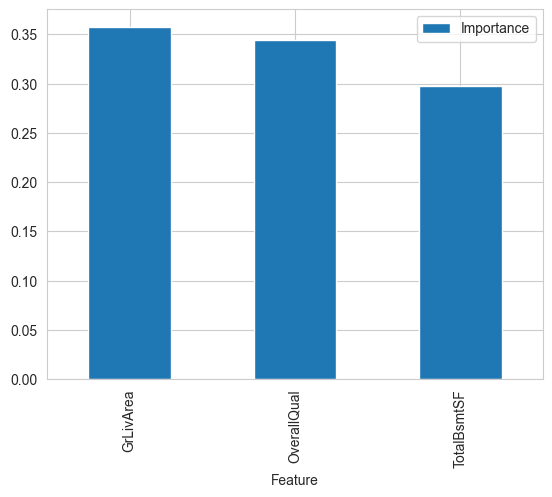

In [52]:

# Extract steps before scaling (up to but not including 'feat_selection')
data_cleaning_feat_eng_steps = 12
X_transformed = Pipeline(
    best_regressor_pipeline_random_forest.steps[:data_cleaning_feat_eng_steps]
    ).transform(X_train)

# Manually assign column names from X_train, after all previous transformations
# (Assumes that the transformation preserves column order)
columns_before_selection = X_train.columns

# If your pipeline drops/adds columns, it's safer to extract
# names before scaling:
# Step 1: run pipeline up to just before 'feat_scaling'
pipeline_before_scaling = Pipeline(
    best_regressor_pipeline_random_forest.steps[:11])
X_engineered = pipeline_before_scaling.transform(X_train)

# Step 2: wrap in DataFrame to keep column names
X_engineered_df = pd.DataFrame(X_engineered, columns=X_engineered.columns)

# Step 3: get support from SelectFromModel
mask = best_regressor_pipeline_random_forest['feat_selection'].get_support()
best_features = X_engineered_df.columns[mask].to_list()

# Step 4: plot feature importances
df_feature_importance_random_forest = pd.DataFrame({
    'Feature': best_features,
    'Importance': best_regressor_pipeline_random_forest[
        'model'].feature_importances_
}).sort_values(by='Importance', ascending=False)

print(f"* These are the {len(best_features)} "
      f"most important features in descending order:\n"
      f"{df_feature_importance_random_forest['Feature'].to_list()}")

# Plot
df_feature_importance_random_forest.plot(kind='bar', x='Feature', y='Importance')
plt.show()


## Model Selection Justification: ExtraTreesRegressor

After evaluating multiple models including Ridge, Lasso, and RandomForestRegressor, the ExtraTreesRegressor was selected as the final estimator for the following key reasons:

* Best Overall Cross-Validation Score
    * ExtraTreesRegressor achieved the highest mean cross-validation R² score: 0.8264, compared to:

        * Lasso: 0.8147

        * Ridge: 0.7762

        * RandomForestRegressor: 0.7853

    * It also maintained a low standard deviation (≈ 0.0345), indicating stable performance across all folds.

* Extra Trees introduces additional randomness during the split selection process (random thresholds instead of best thresholds), which:

    * Reduces variance compared to standard Random Forests.

    * Provides better generalization to unseen data.

* Efficient and Scalable

    * The model is well-suited for datasets with many features and handles both numerical and categorical data (after encoding) efficiently.

    * It's parallelizable and scales better for grid search compared to some other ensemble models.

* Outperformed Alternatives in Grid Search

    Compared to:

    *  Lasso, which performed well but lacked the ability to capture non-linear relationships.

    * Ridge, which consistently underperformed.

    * RandomForestRegressor, which had higher variance (std ≈ 0.056–0.092), and lower mean scores.

**Conclusion**

ExtraTreesRegressor was chosen for its strong predictive performance, low variance, and robustness to overfitting. It offered the best trade-off between bias and variance, making it an ideal choice for the regression task of predicting Ames house prices.



## Evaluate on Train and Test Sets

In [35]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


def regression_performance(X_train, y_train, X_test, y_test, pipeline):
    print("Model Evaluation \n")
    print("* Train Set")
    regression_evaluation(X_train, y_train, pipeline)
    print("* Test Set")
    regression_evaluation(X_test, y_test, pipeline)


def regression_evaluation(X, y, pipeline):
    prediction = pipeline.predict(X)
    print('R2 Score:', r2_score(y, prediction).round(3))
    print('Mean Absolute Error:', mean_absolute_error(y, prediction).round(3))
    print('Mean Squared Error:', mean_squared_error(y, prediction).round(3))
    print('Root Mean Squared Error:', np.sqrt(
        mean_squared_error(y, prediction)).round(3))
    print("\n")


def regression_evaluation_plots(X_train, y_train, X_test, y_test, pipeline,
                                alpha_scatter=0.5):
    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
    sns.scatterplot(x=y_train, y=pred_train, alpha=alpha_scatter, ax=axes[0])
    sns.lineplot(x=y_train, y=y_train, color='red', ax=axes[0])
    axes[0].set_xlabel("Actual")
    axes[0].set_ylabel("Predictions")
    axes[0].set_title("Train Set")

    sns.scatterplot(x=y_test, y=pred_test, alpha=alpha_scatter, ax=axes[1])
    sns.lineplot(x=y_test, y=y_test, color='red', ax=axes[1])
    axes[1].set_xlabel("Actual")
    axes[1].set_ylabel("Predictions")
    axes[1].set_title("Test Set")

    plt.show()


Evaluate Performance

Model Evaluation 

* Train Set
R2 Score: 0.9
Mean Absolute Error: 15145.612
Mean Squared Error: 615823409.846
Root Mean Squared Error: 24815.79


* Test Set
R2 Score: 0.812
Mean Absolute Error: 20286.002
Mean Squared Error: 1298963425.999
Root Mean Squared Error: 36041.135




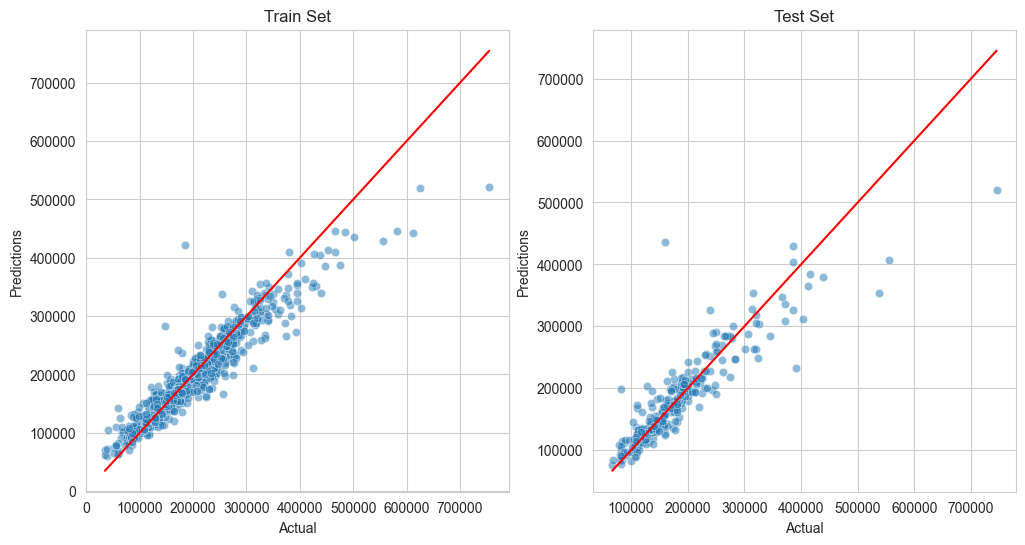

In [36]:
regression_performance(X_train, y_train, X_test, y_test,
                       best_regressor_pipeline_extra_trees)
regression_evaluation_plots(X_train, y_train, X_test, y_test,
                            best_regressor_pipeline_extra_trees)


**Overfitting Mitigation Strategy**

During initial evaluation, the ExtraTreesRegressor demonstrated strong performance on the training set but exhibited signs of overfitting, as seen from the gap in R² scores between the training and test sets.

To reduce this, the following steps were taken:

* Regularization via hyperparameter tuning

The initial model used relatively loose parameters:
```
'model__max_depth': [None, 10, 20, 30],
'model__min_samples_split': [2, 5, 10],
'model__min_samples_leaf': [1, 2, 4],
'model__criterion': ['squared_error', 'absolute_error']
```
These were adjusted to enforce regularization:
```
'model__max_depth': [5, 10, 15, 20],
'model__min_samples_split': [5, 10, 15],
'model__min_samples_leaf': [2, 4, 6],
'model__criterion': ['absolute_error'],  # Dropped squared_error, to reduce sensitivity to outliers.
```
* Reduced model complexity
    * Removed very deep trees (None) and limited growth to reduce variance.
    * Increased min_samples_leaf and min_samples_split to require more data per split and leaf.

* Improved cross-validation stability

    Cross-validation folds increased from 3 to 5, offering a more reliable estimate of generalization and reducing the chance of optimistic bias.

**Result**

After applying the changes:

* The model's training R² dropped slightly (from 0.96 to 0.90), indicating reduced overfitting.

* The test R² remained strong at 0.812, confirming improved generalization.

* The gap between train and test performance narrowed, with MAE and RMSE remaining within acceptable ranges.

This final version strikes a balance between bias and variance, and is well-suited for real-world prediction tasks on unseen data.


---

# Push files to Repo

We will generate the following files

* Train set
* Test set
* Modeling pipeline
* features importance plot

In [37]:
import joblib
import os

version = 'v1'
file_path = f'outputs/ml_pipeline/predict_sale_price/{version}'

try:
    os.makedirs(name=file_path)
except Exception as e:
    print(e)


[WinError 183] Cannot create a file when that file already exists: 'outputs/ml_pipeline/predict_sale_price/v1'


## Train Set: features and target

In [38]:
X_train.head()


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd
618,1828,0.0,NaN,Av,48,NaN,1774,NaN,774,Unf,...,11694,90.0,452.0,108,5,9,1822,NaN,2007,2007
870,894,0.0,2.0,No,0,Unf,894,NaN,308,NaN,...,6600,60.0,0.0,0,5,5,894,NaN,1962,1962
92,964,0.0,2.0,No,713,ALQ,163,NaN,432,Unf,...,13360,80.0,0.0,0,7,5,876,NaN,1921,2006
817,1689,0.0,3.0,No,1218,GLQ,350,NaN,857,RFn,...,13265,NaN,148.0,59,5,8,1568,NaN,2002,2002
302,1541,0.0,3.0,No,0,Unf,1541,NaN,843,RFn,...,13704,118.0,150.0,81,5,7,1541,NaN,2001,2002


In [39]:
X_train.to_csv(f"{file_path}/X_train.csv", index=False)


In [40]:
y_train


618     314813
870     109500
92      163500
817     271000
302     205000
         ...  
763     337000
835     128000
1216    112000
559     234000
684     221000
Name: SalePrice, Length: 1168, dtype: int64

In [41]:
y_train.to_csv(f"{file_path}/y_train.csv", index=False)


## Test Set: features and target

In [42]:
X_test.head()


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd
529,2515,0.0,4.0,No,1219,Rec,816,NaN,484,NaN,...,32668,NaN,NaN,0,3,6,2035,NaN,1957,1975
491,958,620.0,3.0,No,403,BLQ,238,NaN,240,Unf,...,9490,79.0,0.0,0,7,6,806,NaN,1941,1950
459,979,224.0,3.0,No,185,LwQ,524,NaN,352,Unf,...,7015,NaN,161.0,0,4,5,709,NaN,1950,1950
279,1156,866.0,4.0,No,392,BLQ,768,0.0,505,Fin,...,10005,83.0,299.0,117,5,7,1160,288.0,1977,1977
655,525,NaN,3.0,No,0,Unf,525,NaN,264,Unf,...,1680,21.0,381.0,0,5,6,525,NaN,1971,1971


In [43]:
X_test.to_csv(f"{file_path}/X_test.csv", index=False)


In [44]:
y_test


529     200624
491     133000
459     110000
279     192000
655      88000
         ...  
326     324000
440     555000
1387    136000
1323     82500
61      101000
Name: SalePrice, Length: 292, dtype: int64

In [45]:
y_test.to_csv(f"{file_path}/y_test.csv", index=False)


## Modelling pipeline

ML pipeline for predicting SalePrice

In [46]:
best_regressor_pipeline_extra_trees


Pipeline(steps=[('drop_features',
                 DropFeatures(features_to_drop=['EnclosedPorch',
                                                'WoodDeckSF'])),
                ('median_imputer',
                 MeanMedianImputer(variables=['2ndFlrSF', 'BedroomAbvGr',
                                              'LotFrontage'])),
                ('constant_imputer',
                 ArbitraryNumberImputer(arbitrary_number=1900.0,
                                        variables=['GarageYrBlt'])),
                ('mode_imputer',
                 CategoricalImputer(imputation_method='frequent',
                                    varia...
                ('drop_correlated',
                 DropFeatures(features_to_drop=['1stFlrSF', 'GarageYrBlt'])),
                ('feat_scaling', StandardScaler()),
                ('feat_selection',
                 SelectFromModel(estimator=ExtraTreesRegressor(random_state=0))),
                ('model',
                 ExtraTreesRegressor(criterion='absolute_error', max_depth=15,
                                     max_features='sqrt', min_samples_leaf=2,
                                     min_samples_split=5, n_estimators=200,
                                     random_state=0))])

In [47]:
joblib.dump(value=best_regressor_pipeline_extra_trees,
            filename=f"{file_path}/extra_trees_regressor_pipeline.pkl")


['outputs/ml_pipeline/predict_sale_price/v1/extra_trees_regressor_pipeline.pkl']

## Feature importance plot

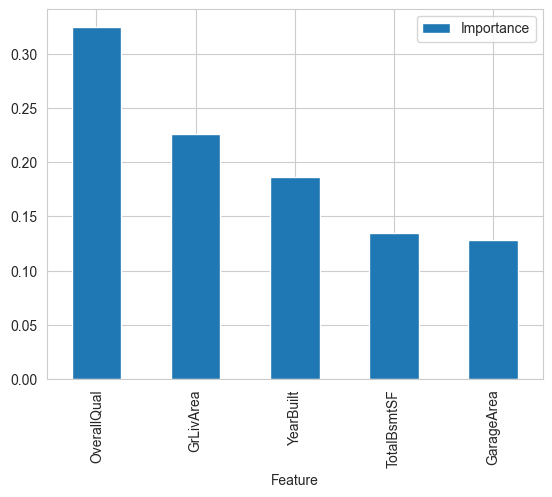

In [53]:
df_feature_importance_extra_trees.plot(kind='bar', x='Feature', y='Importance')
plt.show()


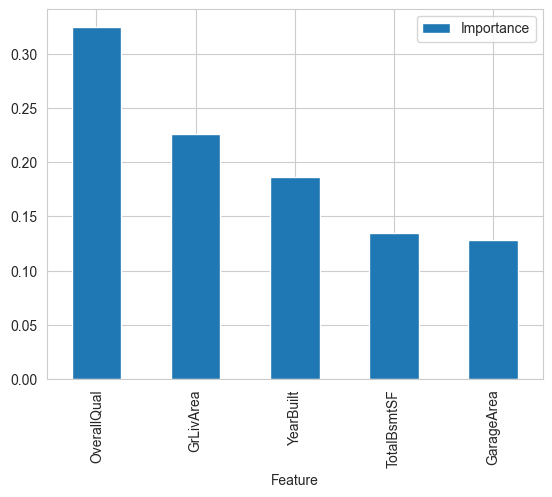

In [54]:
df_feature_importance_extra_trees.plot(kind='bar', x='Feature', y='Importance')
plt.savefig(f'{file_path}/features_importance.png', bbox_inches='tight')
